In [7]:
# ==============================================================================
# CELL 1: DEVELOPMENT UTILITIES & ENVIRONMENT ALIGNMENT
# ==============================================================================
# 1. Enable automatic reloading of modified local scripts
%load_ext autoreload
%autoreload 2

import sys
import os

# This bridges the notebook to the custom /src modules
sys.path.append(os.path.abspath('.'))

print("🚀 Environment aligned! Notebook is linked to your /src architecture.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 Environment aligned! Notebook is linked to your /src architecture.


## Part 1: Data Ingestion & Local Storage Setup

In this section, we programmatically pull two localized datasets from Kaggle containing Philippine-context SMS spam and smishing messages:
1. `bwandowando/philippine-spam-sms-messages`
2. `scottleechua/ph-spam-marketing-sms-w-timestamps`

We leverage `kagglehub` to handle API communication. Our backend script copies these files out of the system cache into our tracking repository (`data/1_raw/`), normalizes their conflicting schemas, strips cross-over duplicate texts, and converts string classes into strict integers ($0$ for Ham, $1$ for Smishing/Spam) inside `data/2_interim/`.

In [8]:
from src.loaders.data_loader import load_and_combine_ph_data

# Triggers the automated extraction from the Kaggle Cache Matrix
df_raw = load_and_combine_ph_data()

# Render descriptive outputs directly in your log dashboard
print("\n--- Remaining Targets for Machine Learning Evaluation ---")
print(df_raw['category'].value_counts())

📥 Loading Dataset 1 (bwandowando)...
📥 Loading Dataset 2 (scottleechua)...
🏁 Data Ingestion Complete! Merged shape: (2731, 6)

--- Remaining Targets for Machine Learning Evaluation ---
category
smishing    1843
ads          752
gov          133
notifs         3
Name: count, dtype: int64


In [9]:
from src.preprocessing.text_cleaner import SmishingFeatureExtractor

extractor = SmishingFeatureExtractor()
df_features = extractor.extract_meta_features(df_raw)

print("✅ Meta-features appended successfully!")
df_features[['text', 'text_len', 'has_url',
             'urgency_score', 'hour_received', 'label']].head()

✅ Meta-features appended successfully!


,text,text_len,has_url,urgency_score,hour_received,label
137,Nice! You received a P10 voucher from Maya. Us...,156,0,1,18,0
138,Nice! You received a P20 voucher from Maya. Us...,156,0,1,11,0
139,Nice! You received a P10 voucher from Maya. Us...,156,0,1,16,0
140,Nice! You received a P20 voucher from Maya. Us...,156,0,1,12,0
141,Nice! You received a P10 voucher from Maya. Us...,156,0,1,13,0


## Part 4: Feature Matrix Partitioning & Vectorization
We isolate our engineered numerical features from raw target flags ($y$). To ensure our text metrics remain untainted by validation data leakage, we partition our data arrays into training and evaluation blocks *before* extracting our text TF-IDF tokens.

In [11]:
# ==============================================================================
# CELL 7: FEATURE EXTRACTION & SPLITTING
# ==============================================================================
from sklearn.model_selection import train_test_split
from src.preprocessing.vectorizers import SmishingTfidfVectorizer

# 1. Isolate target variable y from your features dataframe
y = df_features['label']

# 2. Build metadata feature list from df_features
meta_columns = ["text_len", "has_url", "urgency_score", "hour_received"] + \
    [col for col in df_features.columns if col.startswith("sc_")]
X_meta = df_features[meta_columns].values
X_text_raw = df_features["text"]

# 3. Stratified Split to preserve exact class imbalances
X_text_train_raw, X_text_test_raw, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text_raw, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and run our modular Vectorizer Layer
tfidf_handler = SmishingTfidfVectorizer(max_features=10000)
X_text_train = tfidf_handler.fit_transform(X_text_train_raw)
X_text_test = tfidf_handler.transform(X_text_test_raw)

# Save the matrix state for potential final Streamlit production integration
tfidf_handler.save_vectorizer()

print("\n--- Feature Matrix Dimensionality Verification ---")
print(
    f"X_text_train Shape: {X_text_train.shape} | X_meta_train Shape: {X_meta_train.shape}")
print(
    f"X_text_test Shape:  {X_text_test.shape}  | X_meta_test Shape:  {X_meta_test.shape}")

📦 TF-IDF Vectorizer saved to saved_models/tfidf_vectorizer.pkl

--- Feature Matrix Dimensionality Verification ---
X_text_train Shape: (2184, 10000) | X_meta_train Shape: (2184, 7)
X_text_test Shape:  (547, 10000)  | X_meta_test Shape:  (547, 7)


--- Individual Model Performance ---
✅ SVM (Text): Complete
✅ Naive Bayes (Text): Complete
✅ Logistic Regression (Text): Complete
✅ Random Forest (Metadata): Complete
✅ XGBoost (Metadata Base): Complete


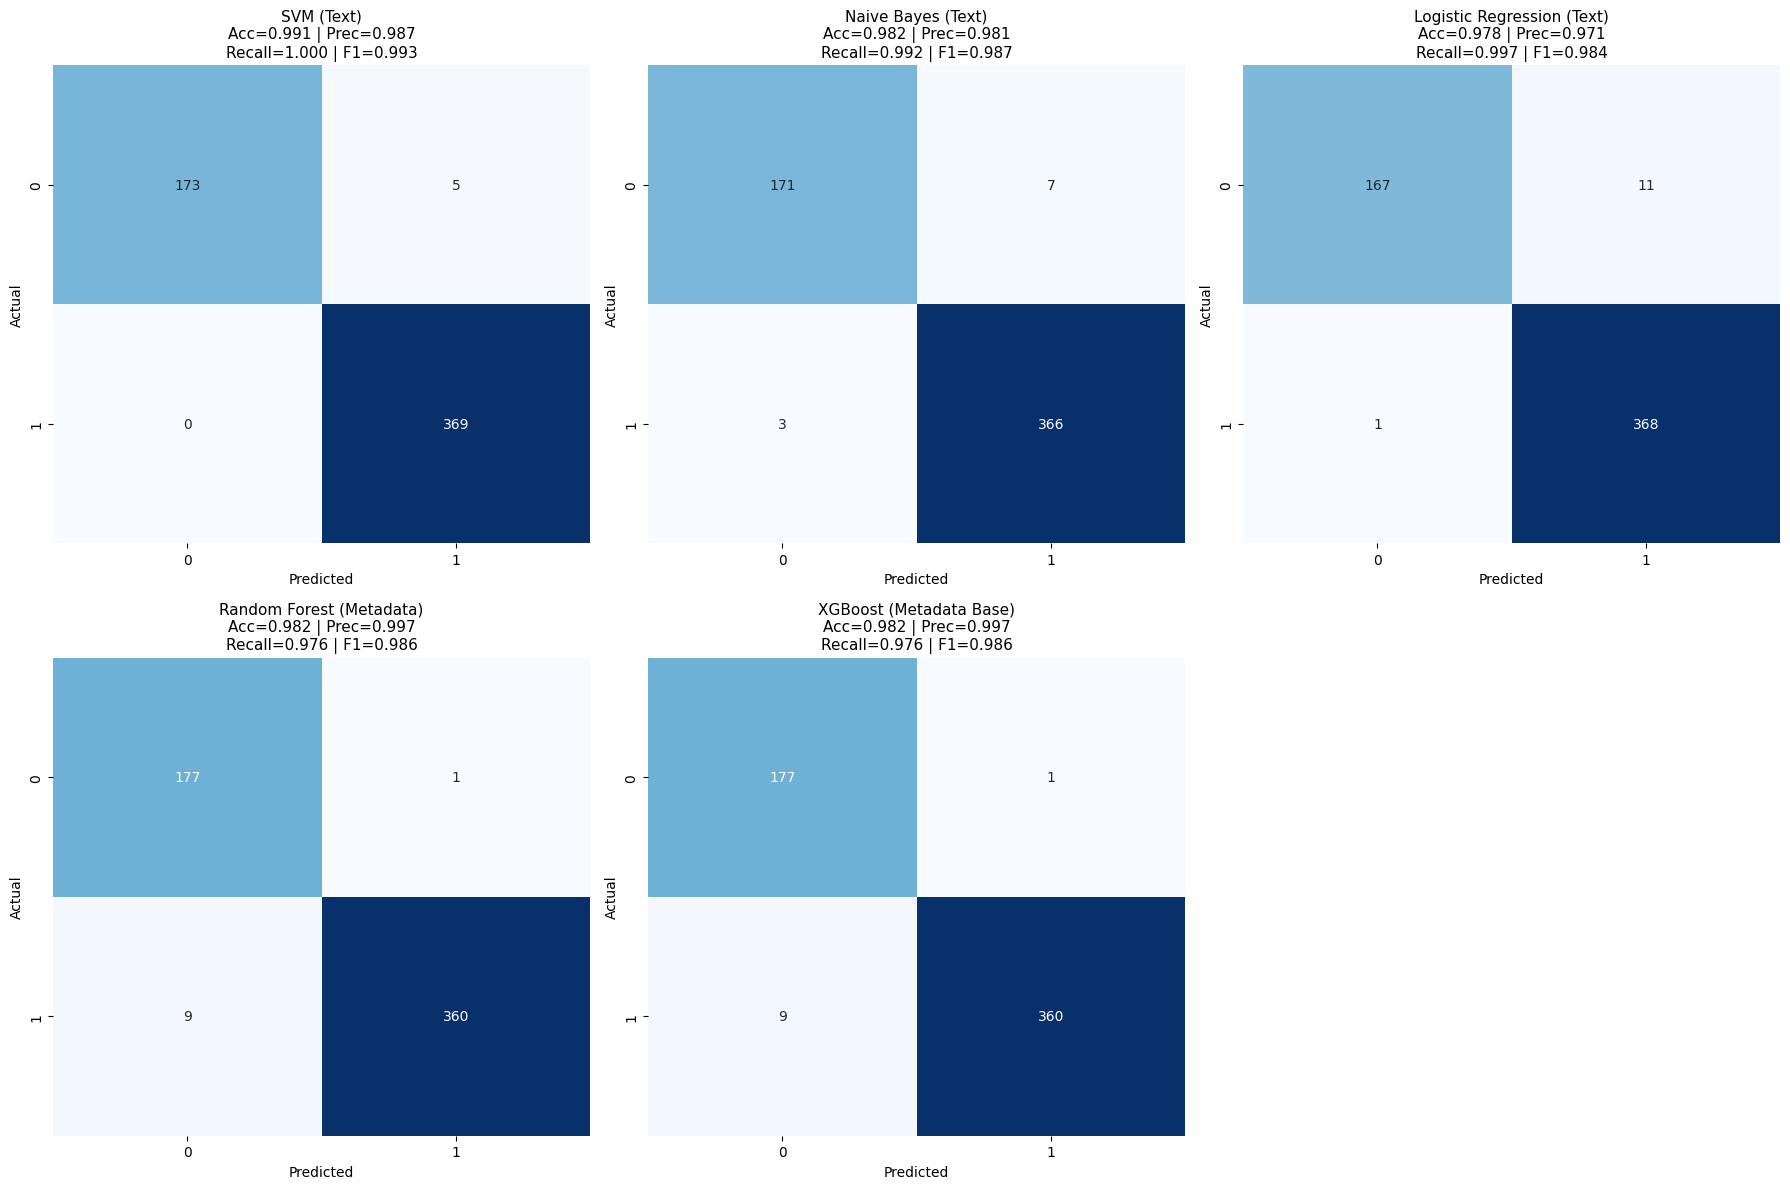


--- Final Model Performance Summary Table ---


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (Text),0.990859,0.986631,1.00000,0.993271
1,Naive Bayes (Text),0.981718,0.981233,0.99187,0.986523
2,Random Forest (Metadata),0.981718,0.997230,0.97561,0.986301
3,XGBoost (Metadata Base),0.981718,0.997230,0.97561,0.986301
4,Logistic Regression (Text),0.978062,0.970976,0.99729,0.983957


In [12]:
# ==============================================================================
# CELL 8: ENSEMBLE EVALUATION & HEATMAP GRAPHING
# ==============================================================================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from src.evaluation.metrics import evaluate_and_plot_models

# Define your algorithm architecture dictionaries mapping to their respective inputs
models_config = {
    "SVM (Text)": (SVC(kernel="linear", random_state=42), X_text_train, X_text_test),
    "Naive Bayes (Text)": (MultinomialNB(), X_text_train, X_text_test),
    "Logistic Regression (Text)": (LogisticRegression(max_iter=1000, random_state=42), X_text_train, X_text_test),
    "Random Forest (Metadata)": (RandomForestClassifier(n_estimators=100, random_state=42), X_meta_train, X_meta_test),
    "XGBoost (Metadata Base)": (XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42), X_meta_train, X_meta_test),
}

# Run the training loops, metric generation, and plotting backend
results_df = evaluate_and_plot_models(models_config, y_train, y_test)

print("\n--- Final Model Performance Summary Table ---")
results_df

## Part 5: Feature Stacking & Hybrid Ensemble Evaluation
To exploit both structural attributes (metadata length, sender profiles) and semantic components (TF-IDF values), we will merge our separate data arrays into a single combined feature space ($X_{\text{combined}}$) and train an overall champion classifier model to maximize our F1-score.